In [68]:
import pickle
import numpy as np
from astropy import units as u
from matplotlib import pyplot as plt


In [69]:
sources = {}

In [70]:
sources['exoplanet_model_10pc'] = {'wavel': [ 1.        ,  1.65517241,  2.31034483,  2.96551724,  3.62068966,
            4.27586207,  4.93103448,  5.5862069 ,  6.24137931,  6.89655172,
            7.55172414,  8.20689655,  8.86206897,  9.51724138, 10.17241379,
           10.82758621, 11.48275862, 12.13793103, 12.79310345, 13.44827586,
           14.10344828, 14.75862069, 15.4137931 , 16.06896552, 16.72413793,
           17.37931034, 18.03448276, 18.68965517, 19.34482759, 20.        ] * u.um, 'pre_screen_astro_flux_ph_sec_m2_um': [0.00060498, 0.00060498, 0.00060498, 0.00060498, 0.00060498,
           0.00022668, 0.00253418, 0.00268088, 0.00537994, 0.00835066,
           0.01565745, 0.02757139, 0.03593947, 0.02976239, 0.0459444 ,
           0.04971564, 0.05218585, 0.05382402, 0.053434  , 0.04288014,
           0.03287376, 0.02876433, 0.02939337, 0.03738533, 0.03979   ,
           0.04464744, 0.04534732, 0.0446788 , 0.0446788 , 0.0446788 ] * u.ph / (u.um * u.s * u.m**2)}

In [71]:
sources['star'] = {'wavel': [ 1.        ,  1.65517241,  2.31034483,  2.96551724,  3.62068966,
            4.27586207,  4.93103448,  5.5862069 ,  6.24137931,  6.89655172,
            7.55172414,  8.20689655,  8.86206897,  9.51724138, 10.17241379,
           10.82758621, 11.48275862, 12.13793103, 12.79310345, 13.44827586,
           14.10344828, 14.75862069, 15.4137931 , 16.06896552, 16.72413793,
           17.37931034, 18.03448276, 18.68965517, 19.34482759, 20.        ] * u.um, 'pre_screen_astro_flux_ph_sec_m2_um': [1.11189881e+08, 4.68664862e+07, 2.23148709e+07, 1.21175571e+07,
           7.25440615e+06, 4.66875854e+06, 3.17299579e+06, 2.25042862e+06,
           1.65416517e+06, 1.25286145e+06, 9.71987481e+05, 7.65231873e+05,
           6.16791114e+05, 5.03236711e+05, 4.15220243e+05, 3.46453077e+05,
           2.92203551e+05, 2.48924161e+05, 2.13963791e+05, 1.85346663e+05,
           1.61603371e+05, 1.41642365e+05, 1.24652712e+05, 1.10042609e+05,
           9.82740972e+04, 8.78684852e+04, 7.85935272e+04, 7.09879992e+04, 6.41638880e+04, 5.80495372e+04] * u.ph / (u.s * u.um * u.m**2)}

In [72]:
sources['exoplanet_model_10pc']['post_screen_astro_flux'] = sources['exoplanet_model_10pc']['pre_screen_astro_flux_ph_sec_m2_um'] * np.pi * (1. * u.m)**2
sources['star']['post_screen_astro_flux'] = sources['star']['pre_screen_astro_flux_ph_sec_m2_um'] * np.pi * (1. * u.m)**2

In [73]:
sources['dark_current'] = 0.02 * u.ph / (u.s * u.pix)

sources['wavel_bin_size'] = 0.655 * u.um

sources['wavel_bin_per_pixel'] = 1. / (u. pix)

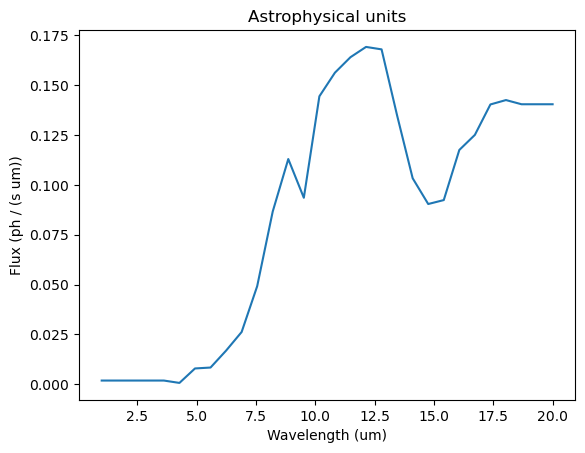

In [74]:
plt.plot(sources['exoplanet_model_10pc']['wavel'],sources['exoplanet_model_10pc']['post_screen_astro_flux'])
plt.xlabel(f'Wavelength ({sources["exoplanet_model_10pc"]["wavel"].unit})')
plt.ylabel(f'Flux ({sources["exoplanet_model_10pc"]["post_screen_astro_flux"].unit})')
plt.title('Astrophysical units')
plt.show()

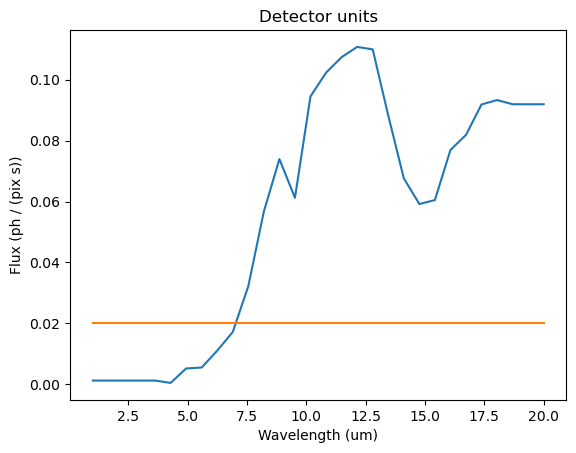

In [78]:
flux_astro_per_pixel = sources['exoplanet_model_10pc']['post_screen_astro_flux'] * sources['wavel_bin_per_pixel'] * sources['wavel_bin_size']
dc = sources['dark_current'] * np.ones(len(sources['exoplanet_model_10pc']['wavel']))

plt.plot(sources['exoplanet_model_10pc']['wavel'], flux_astro_per_pixel, label='Planet signal')
plt.plot(sources['exoplanet_model_10pc']['wavel'], dc, label='Dark current')
plt.xlabel(f'Wavelength ({sources["exoplanet_model_10pc"]["wavel"].unit})')
plt.ylabel(f'Flux ({dc.unit})')
plt.title('Detector units')
plt.show()